#Практична робота №5

##**Тема. Графи. Ациклічні графи**
##**Мета**: набути практичних навичок розв’язання задач топографічного сортування та оцінювання їх асимптотичної складності.
##**Виконав:** Рафієв Б.

###**Завдання для самостійного розв’язання** Моделювання та топологічне сортування графа за допомогою DFS

**Умова:** Задано орієнтований ациклічний граф (ОАГ):  
 - *Вершини:* $V = \{1, 2, 3, 4, 5\}$
 - *Ребра:* $E = \{(1,2), (1,3), (2,4), (3,5), (4,5)\}$

Необхідно побудувати граф, реалізувати алгоритм пошуку в глибину (DFS) для топологічного сортування мовою Python, виконати код та проаналізувати його роботу.  
**1. Візуальна структура графа** Перед кодуванням представимо структуру графа діаграммою, що демонструє напрямки залежностей:  
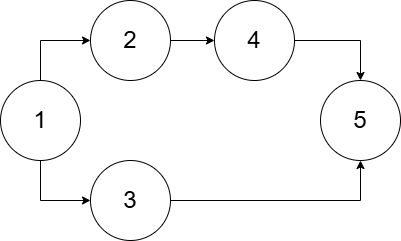  
**2. Програмна реалізація алгоритму DFS на Python** Алгоритм топологічного сортування на основі DFS базується на обході графа: вершина додається в результуючий список після того, як відвідані всі її сусіди (пост-ордер). Оскільки такий підхід записує елементи з кінця, фінальний список реверсується.

In [1]:
def dfs_topological_sort(graph):
    visited = set()
    result = []

    def dfs(vertex):
        visited.add(vertex)

        for neighbor in graph.get(vertex, []):
            if neighbor not in visited:
                dfs(neighbor)

        result.append(vertex)
        
    for vertex in graph:
        if vertex not in visited:
            dfs(vertex)

    return result[::-1]

graph = {
    1: [2, 3],
    2: [4],
    3: [5],
    4: [5],
    5: []
}

topological_order = dfs_topological_sort(graph)
print("Результат топологічного сортування (DFS):", topological_order)

Результат топологічного сортування (DFS): [1, 3, 2, 4, 5]


**Оцінювання асимптотичної складності**  
*Часова складність:* $O(|V| + |E|)$, де $|V|$ — кількість вершин (у нашому випадку 5), а $|E|$ — кількість ребер (у нашому випадку 5). Алгоритм відвідує кожну вершину рівно один раз завдяки перевірці у множині visited та проходить по кожному ребру один раз під час перебору списку сусідів.  
*Просторова складність:* $O(|V|)$ для збереження стану відвіданих вершин, результуючого списку та системного стека викликів рекурсії у найгіршому випадку (якщо граф вироджується в лінійний ланцюжок). Згідно з теоретичними відомостями практичної роботи, алгоритм DFS має таку асимптотичну складність:

###**Висновок:** під час виконання цієї практичної роботи я набув практичних навичок розв’язання задач топографічного сортування та оцінювання їх асимптотичної складності.  
###Контрольні питання:
1. Головна перевага алгоритму Кана полягає в тому, що він працює ітеративно без ризику переповнення стека та автоматично виявляє цикли в графі без додаткових зусиль, тоді як його недоліком є необхідність витрачати пам'ять на підрахунок і збереження вхідних ступенів вершин; з іншого боку, алгоритм DFS простіший у реалізації та не вимагає попереднього аналізу ступенів, але має суттєві недоліки у вигляді ризику переповнення стека (StackOverflow) на глибоких графах і потреби в додатковому триколірному фарбуванні вершин для виявлення циклів.
2. Асимптотична складність обох алгоритмів є однаковою для будь-яких умов, оскільки вони обов'язково обходять кожну вершину та кожне ребро: часова складність як у найкращому, так і в найгіршому випадках становить $O(|V| + |E|)$, а просторова складність (пам'ять) для обох методів завжди становить $O(|V|)$, при цьому для алгоритму Кана вона витрачається на масив ступенів і чергу, а для DFS — на масив відвіданих вершин та системний стек викликів, який досягає свого максимуму в найгіршому випадку, коли граф вироджений у лінійний ланцюжок.
3. Так, обидва алгоритми можна повноцінно застосовувати до зважених графів, оскільки ваги на ребрах жодним чином не впливають на сам топологічний порядок, який будується виключно на основі напрямку ребер та зв'язків між вузлами; порівнюючи їх, алгоритм Кана є зручнішим, якщо паралельно із сортуванням потрібно динамічно обчислювати найкоротші чи найдовші шляхи методом «вперед», тоді як DFS частіше використовують для класичного аналізу критичних шляхів у проектах, роблячи розрахунки на кроці повернення з рекурсії («назад»).
4. Структура графа безпосередньо впливає на накладні витрати: на розріджених графах з малою кількістю ребер DFS працює дещо швидше, бо не потребує попереднього лінійного проходу для підрахунку ступенів вершин, тоді як на густих графах з великою кількістю ребер або на графах у вигляді довгих ланцюжків ітеративний алгоритм Кана демонструє кращу стабільність, оскільки DFS у цих умовах здійснює дуже глибокі рекурсивні переходи, що призводить до значних затримок на виділення пам'яті під стек.
5. Основним обмеженням для обох алгоритмів є наявність циклів у графі, оскільки топологічне сортування можливе лише для ациклічних графів (ОАГ), при цьому алгоритм Кана в такій ситуацій просто зупиниться і поверне помилку, а класичний DFS без модифікації зациклиться; крім того, алгоритм Кана обмежений статичними задачами й найкраще підходить для динамічного керування чергами завдань у реальному часі, тоді як DFS обмежений глибиною стека системи й частіше використовується як складова частина інших комплексних обходів.
6. Для оптимізації алгоритму Кана слід використовувати низькорівневі масиви замість важких об'єктів на кшталт set, замінити чергу на швидкий двосторонній список deque та зберігати граф у вигляді компактного списку суміжності для швидкого доступу до пам'яті, в той час як для оптимізації DFS найефективнішим є повна відмова від рекурсії на користь ітеративного підходу з використанням власного явного стека у пам'яті, а також заміна динамічних структур відстеження відвіданих вершин на прості масиви прапорців фіксованого розміру.